# Quick intro to the cool_maps wrapper around cartopy. 

In [1]:
import cool_maps.plot as cplt
# import cartopy.crs as ccrs

In [2]:
cplt.get_engine()

'cartopy'

In [3]:
cplt.set_engine('basemap')


# Define map extent
To create a map, we need to define the extent of the map.

cool_maps uses the standard Cartopy extent format, (x0, x1, y0, y1)

* x0 = Westernmost longitude
* x1 = Easternmost longitude
* y0 = Southernmost latitude
* y1 = Northernmost latitude

This variable can be either a list (mutable) or a tuple (immutable). It doesn't really matter.

### Let's take a look at creating a map of the Gulf of Mexico

Create a variable, extent, that contains the bounding box for the GoM.

In [4]:
# Gulf of Mexico
# extent = [-99, -79, 18, 31]

# Mid Atlantic Bight
extent = [-77, -69, 34, 42]

In [5]:
# This is a quick command to display the docstring in your Jupyter notebook
cplt.create?

Signature:
cplt.create(
    extent,
    proj=None,
    data_proj=None,
    features=True,
    edgecolor='black',
    landcolor='tan',
    oceancolor=None,
    coast='full',
    ticks=True,
    gridlines=False,
    bathymetry=False,
    isobaths=(-1000, -100),
    bathymetry_method='contour',
    bathymetry_file=None,
    xlabel=None,
    ylabel=None,
    tick_label_left=True,
    tick_label_right=False,
    tick_label_bottom=True,
    tick_label_top=False,
    decimal_degrees=False,
    labelsize=14,
    ax=None,
    figsize=(11, 8),
    zorder=0,
    engine=None,
    basemap_kwargs=None,
)
Docstring:
Create a map within a certain extent using the selected mapping engine.

Args:
    extent (tuple or list): Extent (x0, x1, y0, y1) of the map in geographic coordinates.
    proj (optional): Projection spec. Accepts Cartopy CRS objects, supported projection strings, or Basemap kwargs.
    data_proj (optional): Data CRS when using cartopy. Accepts Cartopy CRS or supported projection strings

As you can see in the docstring for this function, the only required parameter is extent. Every other parameter is optional. We already defined the extent of the Gulf of Mexico in the cell above. Let's call the function with only the required parameter, extent.

(<Figure size 1100x800 with 1 Axes>, <Axes: >)

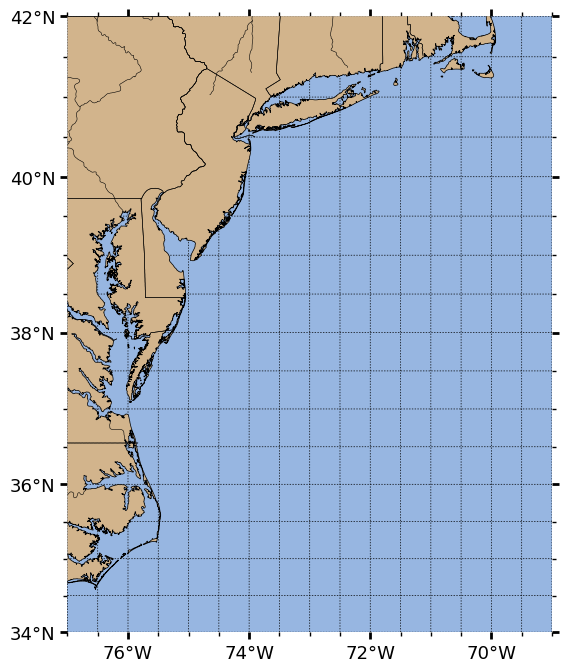

In [6]:
cplt.create(extent, gridlines=True)

In [ ]:
import cartopy.crs as ccrs

: 

A map is created using the function defaults. This map is in the Mercator projection with tan land, a blue ocean, and black coastlines. The function also added lakes, rivers, state lines, and country borders to the map.

## Let's use the function with another projection, LambertCylindrical

(<Figure size 1100x800 with 1 Axes>, <Axes: >)

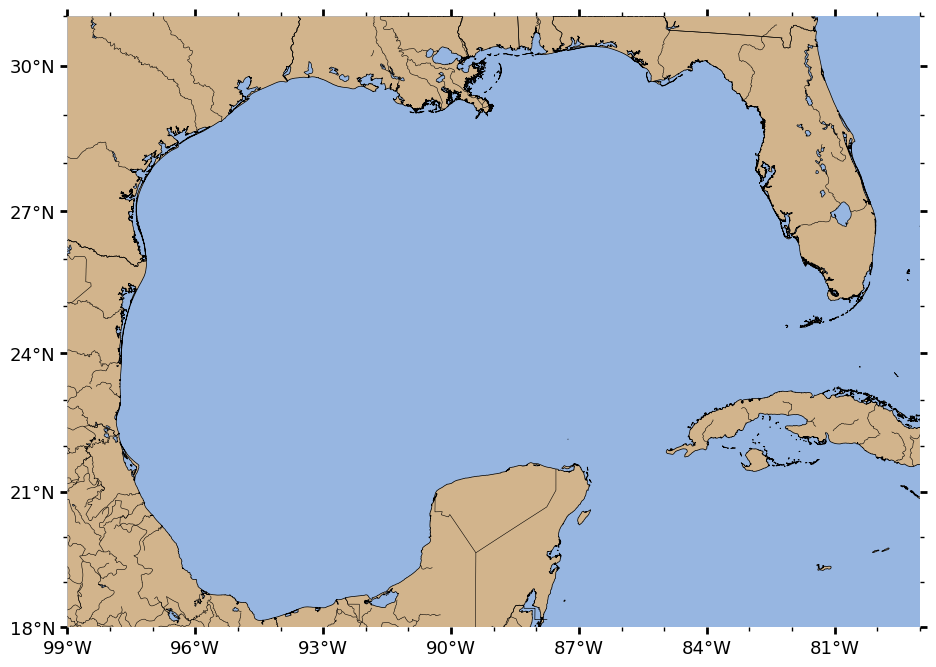

: 

In [ ]:
cplt.create(extent, proj=ccrs.Mercator())

This map looks squished vertically. We just wanted to see how we would create the map in another projection.

## Let's change the colors of some of the physical features in our map

(<Figure size 1100x800 with 1 Axes>, <Axes: >)

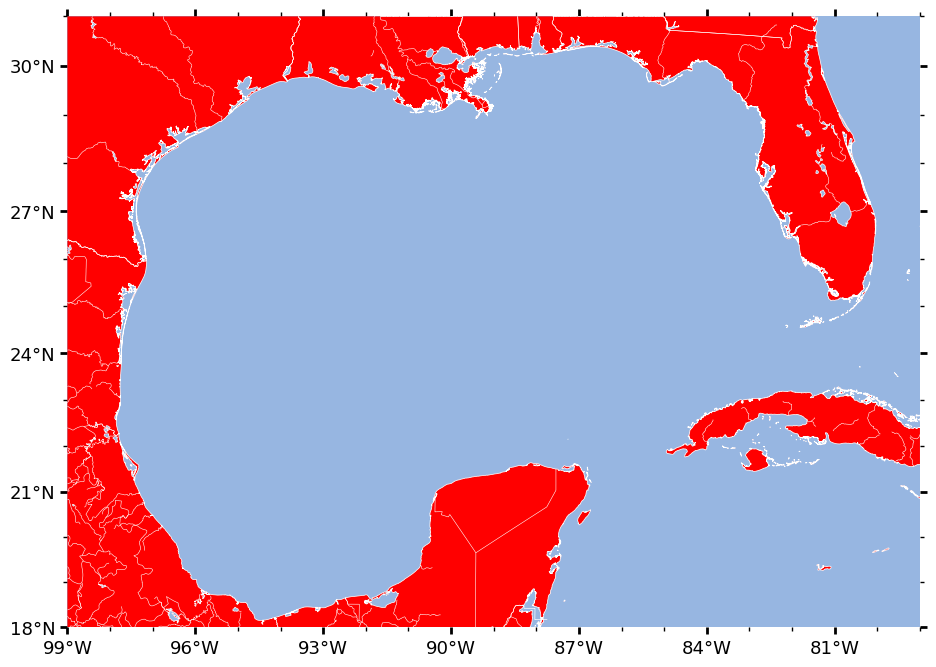

: 

In [ ]:
cplt.create(extent, proj='mercator', landcolor='red', edgecolor='white')

## Create a map without ticks

(<Figure size 1100x800 with 1 Axes>, <Axes: >)

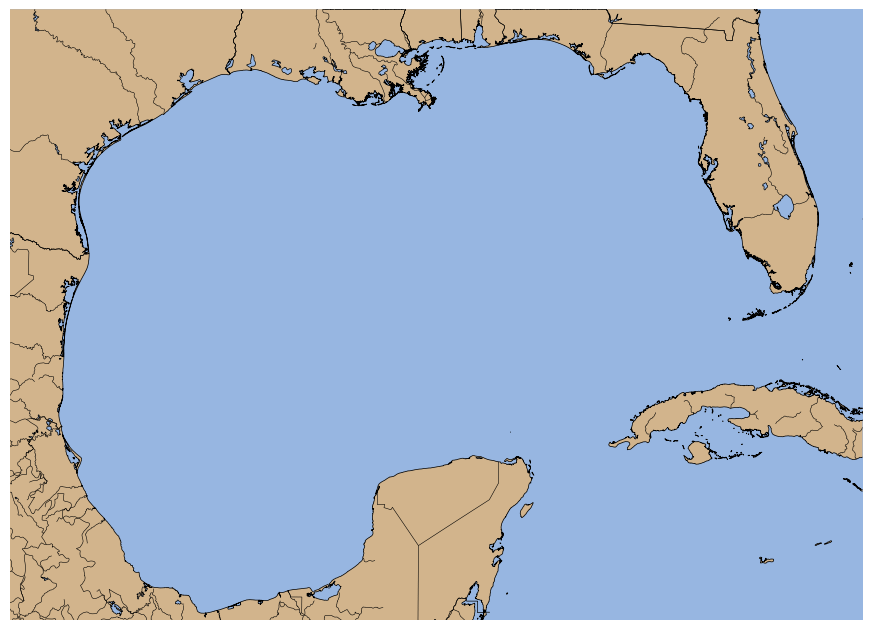

: 

In [ ]:
cplt.create(extent, proj='mercator', ticks=False)

## Create a map with bathymetry contours. 
The defaults are 1000 and 100m contour lines

In [ ]:
cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True)

: 

## We can change the bathymetry contours with by passing a tuple or list to the parameter, isobaths.
Here we will create isobaths of 1000, 500, and 10m

In [ ]:
cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True, isobaths=(-1000, -500, -10))

: 

## Let's adjust the figsize of the map so we can see the contour line labels easier.
We will create a large map with a 16:9 aspect ratio, which is the aspect ratio of powerpoint slides.

In [ ]:
cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True, isobaths=(-1000, -500, -10), figsize=(32,18))

: 

## We can create a blank map.
Setting features=False, will create a blank map, but still in the specified projection. We can fully customize the map afterwards.

In [ ]:
fig, ax = cplt.create(extent, features=False, ticks=False)

: 

In [ ]:
# Create an empty map without the 'automatic features', then add them back
# manually with custom colors/resolution.
#
# Note: the previous version of this cell called cartopy-only methods directly
# (ax.add_feature, ax.set_extent) -- that breaks under the basemap engine we
# selected above. cplt.add_features() is the engine-agnostic way to do the same
# customization; it infers the engine from `ax` automatically.
fig, ax = cplt.create(extent, features=False, ticks=False)

cplt.add_features(
    ax,
    edgecolor="black",
    landcolor="tan",
    oceancolor=None,  # engine default water color
    coast="high",
    zorder=0.1,
)


## There are some other functions in cool_maps. 
You can use help(cplt) to see all available functions. cplt is the name of your imported module

In [ ]:
help(cplt)

: 

## We can use the export_fig to save our figures
This is a wrapper around .savefig() that minimizes whitespace around the plot.

In [ ]:
import os
import matplotlib.pyplot as plt

save_path = os.getcwd()
print(save_path)

fig, ax= cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True, isobaths=(-1000, -500, -10), figsize=(16,9))
cplt.export_fig(save_path, "test.png")
plt.close()

: 

Let's load the plot we just saved

In [ ]:
from IPython.display import Image
Image(filename='test.png') 

: 

## Save your figure as a pickle file
We can serialize the figure that we created in order to reuse it again in the future. This saves the trouble of processing it everytime we make a plot.

In [ ]:
fig, ax= cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True, isobaths=(-1000, -500, -10), figsize=(16,9))
cplt.save_fig(fig, save_path, "test.pkl")
plt.close()

: 

## Load your pickled figure

In [ ]:
fig, ax = cplt.load_fig(os.path.join(save_path, "test.pkl"))
plt.plot(-87, 26, 'ro', markersize=12, transform=ccrs.PlateCarree())

: 

## Calling get_bathymetry() directly

`get_bathymetry()` (used internally by `cplt.create(bathymetry=True)`) downloads GEBCO bathymetry
over OpenDAP and caches it to disk. Large extents are automatically split into 10-degree tiles before
being requested from the server, since the THREDDS server rejects single requests that are too large,
and the tiles are stitched back together transparently. Pass `chunk_size=` (in degrees) to change the
tile size, or `chunk_size=None` to disable tiling.

In [ ]:
extent = [-99, -79, 18, 31]

from cool_maps.download import get_bathymetry

bathymetry = get_bathymetry(extent)

: 

In [ ]:
bathymetry

: 

In [ ]:
fig, ax= cplt.create(extent, proj=ccrs.Mercator(), bathymetry=True, isobaths=(-1000, -500, -10), figsize=(16,9))


: 

: 